EXPLORATORY DATA ANALYSIS (EDA)

UNIVARIATE ANALYSIS - NUMERICAL VARIABLES


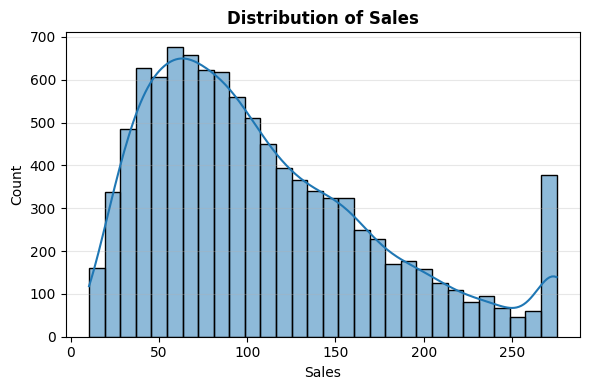

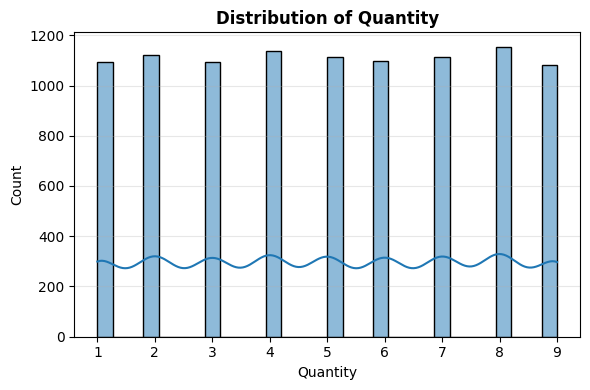

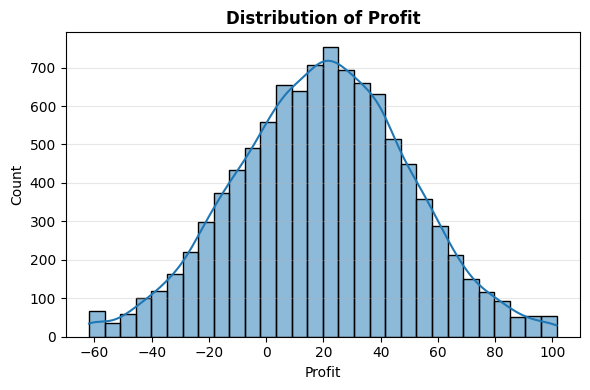

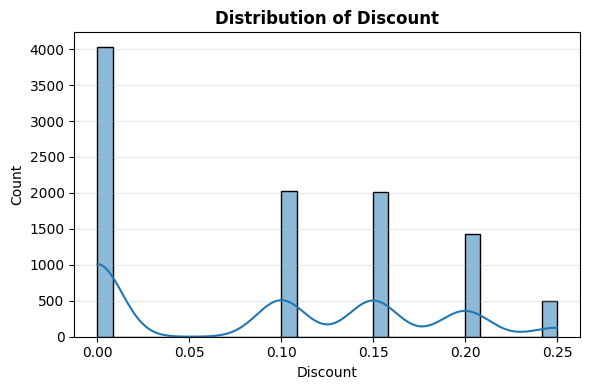


UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES

Segment
Segment
Consumer       4941
Corporate      3028
Home Office    2031
Name: count, dtype: int64

Region
Region
East       2968
Central    2545
West       2512
South      1975
Name: count, dtype: int64

Product_Category
Product_Category
Electronics        3029
Office Supplies    2949
Furniture          2011
Clothing           2011
Name: count, dtype: int64


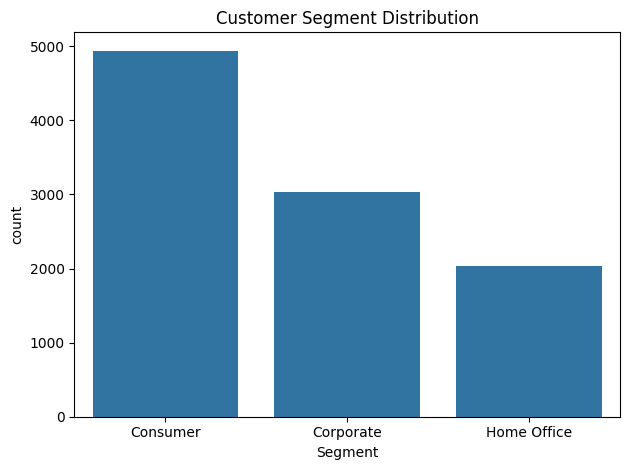


BIVARIATE ANALYSIS

 Sales by Product Category:
Product_Category
Electronics        328422.713112
Office Supplies    321280.864068
Furniture          214958.032671
Clothing           214009.369624
Name: Sales, dtype: float64


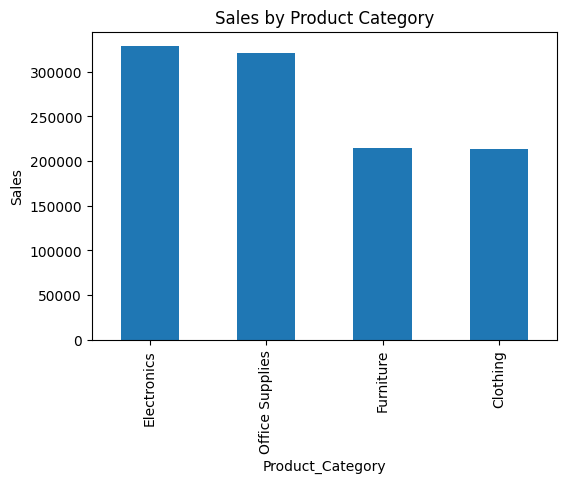


 Sales by Region:
Region
Central    275688.179783
East       318581.371468
South      212070.472519
West       272330.955705
Name: Sales, dtype: float64


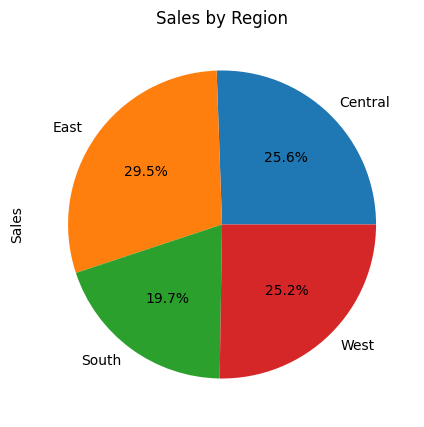


 Correlation Analysis:


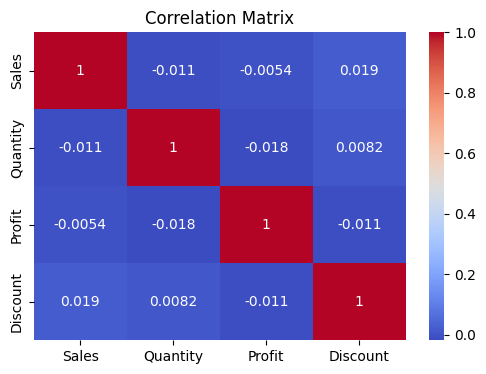


Correlation Coefficients:
             Sales  Quantity    Profit  Discount
Sales     1.000000 -0.010920 -0.005396  0.019058
Quantity -0.010920  1.000000 -0.018266  0.008203
Profit   -0.005396 -0.018266  1.000000 -0.011315
Discount  0.019058  0.008203 -0.011315  1.000000

TIME SERIES ANALYSIS

 Monthly Sales Analysis:


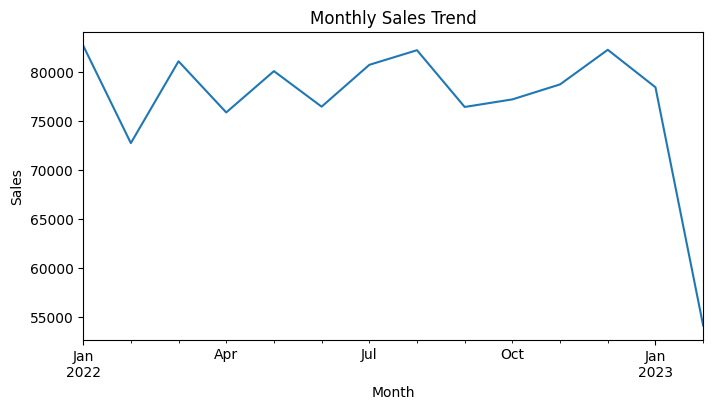

Order_Date
2022-01-31    82670.481463
2022-02-28    72709.329106
2022-03-31    81062.839630
2022-04-30    75840.668735
2022-05-31    80056.231269
2022-06-30    76430.127987
2022-07-31    80699.415429
2022-08-31    82192.585990
2022-09-30    76398.577746
2022-10-31    77173.028698
2022-11-30    78702.980474
2022-12-31    82235.806623
2023-01-31    78408.906190
2023-02-28    54090.000133
Freq: ME, Name: Sales, dtype: float64

 Seasonal Sales Analysis:


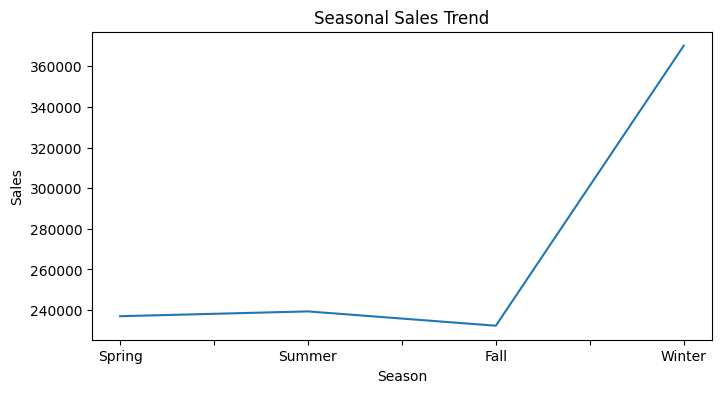

Season
Spring    236959.739634
Summer    239322.129406
Fall      232274.586919
Winter    370114.523515
Name: Sales, dtype: float64

CUSTOMER BEHAVIOR ANALYSIS

 Customer Purchase Frequency:
Average purchases per customer: 5.0352467270896275


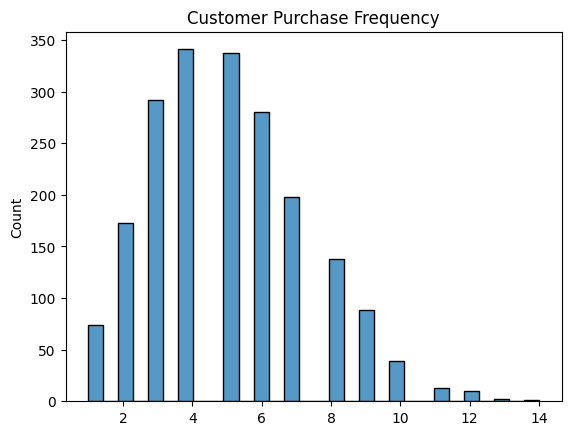


 Top 10 Customers by Revenue:
Customer_ID
CUST1097    1706.776827
CUST1800    1636.436219
CUST1939    1618.691144
CUST1463    1581.229018
CUST1295    1572.574497
CUST0685    1552.585540
CUST0947    1509.431327
CUST1717    1491.505450
CUST1261    1488.475286
CUST1846    1478.577891
Name: Sales, dtype: float64


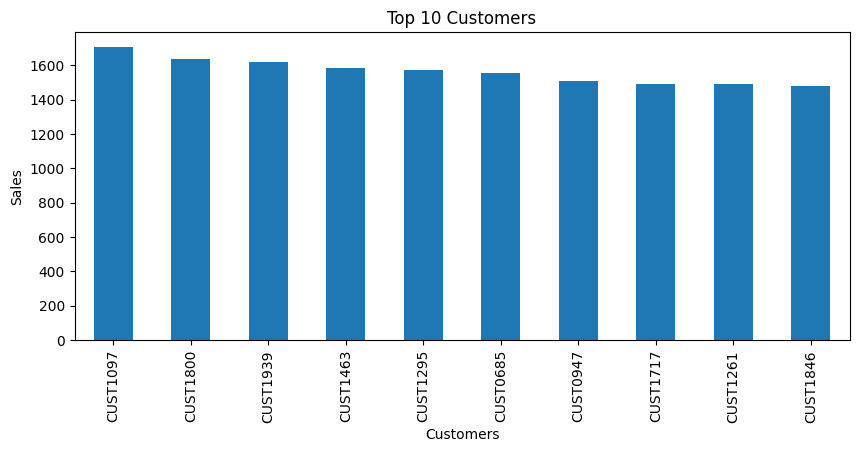


PRODUCT PERFORMANCE ANALYSIS

 Top Selling Products


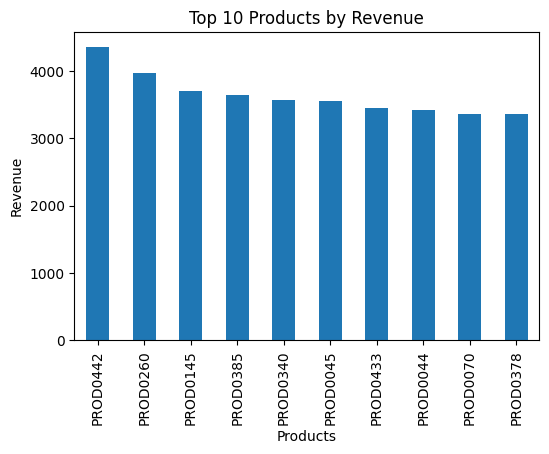


KEY INSIGHTS
Top Category: Electronics
Top Region: East
Customer retention rate: 96.3%

NOTEBOOK 02 COMPLETED SUCCESSFULLY!

✅ Next Step: Open Notebook 03 - RFM & CLV Analysis


In [6]:
# Retail & Marketing Analytics Project
# Notebook 2: Exploratory Data Analysis (EDA)

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Notebook: 02 - Exploratory Data Analysis (EDA)

Objective:
- Univariate analysis
- Bivariate analysis
- Time series analysis
- Customer behavior analysis
- Product performance analysis
- Generate insights
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD CLEANED DATA
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df= pd.read_csv("data/processed/cleaned_retail_sales.csv")

date_cols = ['Order_Date', 'Ship_Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])


print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)


# ============================================================================
# 2. UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")
print("="*80)

num_cols = ['Sales','Quantity','Profit','Discount']

for col in num_cols:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], bins = 30, kde=True)
    plt.title(f'Distribution of {col}', fontweight='bold', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/figures/05_numerical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# 3. UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES")
print("="*80)

cat_cols = ['Segment','Region','Product_Category']

# Print value counts
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

sns.countplot(data=df, x = 'Segment')
plt.title("Customer Segment Distribution")
plt.tight_layout()
plt.savefig('outputs/figures/06_customer_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. BIVARIATE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("BIVARIATE ANALYSIS")
print("="*80)

# Sales by Category

if 'Product_Category' in df.columns and 'Sales' in df.columns:
    print("\n Sales by Product Category:")
    category_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
    print(category_sales)
    category_sales.plot(kind='bar', figsize=(6,4))
    plt.title("Sales by Product Category")
    plt.ylabel("Sales")
    plt.savefig('outputs/figures/07_sales_by_category.png', dpi=300, bbox_inches='tight')
    plt.show()

# Sales by Region
if 'Region' in df.columns and 'Sales' in df.columns:
    print("\n Sales by Region:")
    region_sales = df.groupby('Region')['Sales'].sum()
    print(region_sales)
    region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
    plt.title("Sales by Region")
    plt.savefig('outputs/figures/08_sales_by_region.png')
    plt.show()

# Correlation Analysis

print("\n Correlation Analysis:")

corr = df[num_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot = True, cmap ='coolwarm')
plt.title("Correlation Matrix")
plt.savefig('outputs/figures/09_correlation_matrix.png')
plt.show()

print("\nCorrelation Coefficients:")
print(corr)

# ============================================================================
# 5. TIME SERIES ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("TIME SERIES ANALYSIS")
print("="*80)

print("\n Monthly Sales Analysis:")
monthly_sales = (df.set_index('Order_Date').resample('M')['Sales'].sum())
monthly_sales.plot(figsize=(8,4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig('outputs/figures/10_monthly_sales_trend.png')
plt.show()

print(monthly_sales)

print("\n Seasonal Sales Analysis:")
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
seasonal_sales = df.groupby('Season')['Sales'].sum()
seasonal_sales = seasonal_sales.reindex(season_order)
seasonal_sales.plot(figsize=(8,4))
plt.title("Seasonal Sales Trend")
plt.xlabel("Season")
plt.ylabel("Sales")
plt.savefig('outputs/figures/11_season_sales_trend.png')
plt.show()

print(seasonal_sales)

# ============================================================================
# 6. CUSTOMER BEHAVIOR ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("CUSTOMER BEHAVIOR ANALYSIS")
print("="*80)

# Customer Purchase Frequency

print("\n Customer Purchase Frequency:")

customer_freq = df.groupby('Customer_ID').size()
print("Average purchases per customer:", customer_freq.mean())

sns.histplot(customer_freq, bins=30)
plt.title("Customer Purchase Frequency")
plt.savefig('outputs/figures/12_customer_purchase_frequency.png')
plt.show()

# Top customers

print("\n Top 10 Customers by Revenue:")
top_customers = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

top_customers.plot(kind='bar', figsize=(10,4))
plt.title("Top 10 Customers")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.savefig('outputs/figures/13_top_10_customers.png')
plt.show()

# ============================================================================
# 7. PRODUCT PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PRODUCT PERFORMANCE ANALYSIS")
print("="*80)

# Top Selling Products
print("\n Top Selling Products")

top_products = (df.groupby('Product_ID')['Sales'].sum().sort_values(ascending=False).head(10))

top_products.plot(kind='bar', figsize=(6,4))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.savefig('outputs/figures/14_top_10_products.png')
plt.show()

# ============================================================================
# 9. KEY INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

print("Top Category:", df.groupby('Product_Category')['Sales'].sum().idxmax())
print("Top Region:", df.groupby('Region')['Sales'].sum().idxmax())

repeat_customers = (df.groupby('Customer_ID').size() > 1).mean() * 100
print(f"Customer retention rate: {repeat_customers:.1f}%")   

print("\n" + "="*80)
print("NOTEBOOK 02 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n✅ Next Step: Open Notebook 03 - RFM & CLV Analysis")
print("="*80)